In [95]:
import pandas as pd
import numpy as np

#config
target_dataset = "MIND"
target_model = "LightGCN"
target_method = "VQ"
target_file = f"./csv/summary_{target_dataset}_{target_model}_{target_method}.tsv"


In [96]:
#read csv
df = pd.read_csv(target_file, delimiter="\t")
df['codebook_size'] = df['dir_name'].apply(lambda x: int(x.split("_")[-1])).astype(int)

In [97]:
suma = df.groupby(['codebook_size']).max('mean_valid_recall@20')
suma.sort_values(by='codebook_size', inplace=True, ascending=True)
suma.index = suma.index.astype(str)

Text(0, 0.5, 'Recall@20')

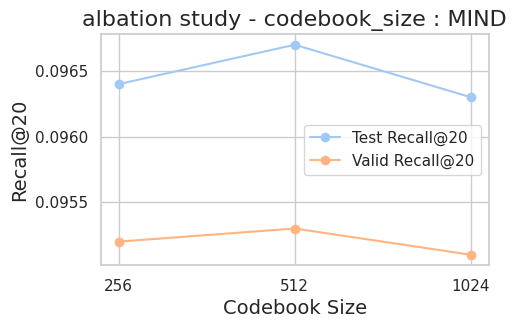

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(5, 3))
sns.set_theme(style="whitegrid")
sns.set_palette("pastel")

plt.plot(suma['mean_test_recall@20'], marker='o', label='Test Recall@20')
plt.plot(suma['mean_valid_recall@20'], marker='o', label='Valid Recall@20')
plt.gca().yaxis.set_major_formatter(plt.FormatStrFormatter('%.4f'))
plt.legend()
plt.title(f"albation study - codebook_size : {target_dataset}", fontsize=16)
plt.xlabel("Codebook Size", fontsize=14)
plt.ylabel("Recall@20", fontsize=14)